In [1]:
import MyBasics as tools
import numpy as np
import matplotlib.pyplot as plt
import random as rd
import os
from scipy.stats import ttest_ind,mannwhitneyu
from scipy.interpolate import make_interp_spline

In [2]:
def plot_significance(list_1,list_2,x1,x2,y1,y2,y_offset,fontsize,linewidth):
    t,p = mannwhitneyu(list_1,list_2)
    print(p)
    if p <= 0.05:
        plt.plot([x1,x1,x2,x2], [y1,max(y1+y_offset, y2+y_offset),max(y1+y_offset, y2+y_offset),y2], linewidth=linewidth, color='k')
    if p <= 0.05 and p > 0.01:
        plt.text((x1+x2)/2,max(y1+y_offset, y2+y_offset)+y_offset,'*',fontsize=fontsize,horizontalalignment='center',va='top')
    elif p <= 0.01 and p > 0.001:
        plt.text((x1+x2)/2,max(y1+y_offset, y2+y_offset)+y_offset,'**',fontsize=fontsize,horizontalalignment='center',va='top')
    elif p <= 0.001 and p > 0.0001:
        plt.text((x1+x2)/2,max(y1+y_offset, y2+y_offset)+y_offset,'***',fontsize=fontsize,horizontalalignment='center',va='top')
    elif p <= 0.0001:
        plt.text((x1+x2)/2,max(y1+y_offset, y2+y_offset)+y_offset,'****',fontsize=fontsize,horizontalalignment='center',va='top')
    return p

In [5]:
workdir='BCR-map_intermediate_files/'
color_list = ['#A94172','#4B2B76','#74377C','#A44829','#C9903A','#DEBD77','#88A6DA']
g1_low_list = []
g1_high_list = []
g2_high_list = []
covid_list = []
inf_list = []
time_list = []
cohort = 'all_vaccination'
g1_file =  cohort+'_G1_SHM.csv'
g1_list = tools.read_csv(workdir+g1_file)
g2_file =  cohort+'_G2_SHM.csv'
g2_list = tools.read_csv(workdir+g2_file)
binder_file = cohort+'_covid_influenza_binder.csv'
binder_list = tools.read_csv(workdir+binder_file)
subject_dict = {}
for i in range(1,56):
    subject_dict[str(i)] = []
    for j in range(5):
        subject_dict[str(i)].append([0,0,0,0,0,0]) # G1 G2 binder
tp_dict = {'pre':0,'1st':1,'2nd':2,'3rd':3,'5th':4}
for line in g1_list[1:]:
    subject = line[1].split('-')[1]
    tp = line[1].split('-')[0]
    if tp in tp_dict:
        subject_dict[subject][tp_dict[tp]][0] = float(line[2])
        subject_dict[subject][tp_dict[tp]][1] = float(line[3])
for line in binder_list[1:]:
    subject = line[1].split('-')[1]
    tp = line[1].split('-')[0]
    if tp in tp_dict:
        subject_dict[subject][tp_dict[tp]][2] = float(line[2])
        subject_dict[subject][tp_dict[tp]][3] = float(line[3])
        
val_index = 0
tp_index = 2
val_list = []
for subject in subject_dict:
    temp = subject_dict[subject]
    val = temp[tp_index][val_index]
    ref = temp[0][val_index]
    if val != 0:
        val_list.append(val)

t1 = sorted(val_list)[-13]
t2 = sorted(val_list)[-13]
print(t1,t2)
print(int(8*(2+np.log10(t1))),int(8*(2+np.log10(t2))))
high_subject = []
low_subject = []
for subject in subject_dict:
    temp = subject_dict[subject]
    val = temp[tp_index][val_index]
    ref = temp[0][val_index]
    if val != 0:
        if val >= t2:
            high_subject.append(subject)
        elif val < t1:
            low_subject.append(subject)
            
high_ref_subject = '22'
low_ref_subject = '6'
color_list = ['dodgerblue','crimson']

1.5432457793391041 1.5432457793391041
17 17


TP1: 0.1411714036362242
TP2: 0.07259587665027824
TP3: 3.361487618210683e-08
TP4: 0.19990638791553655
TP5: 0.41464594231569796


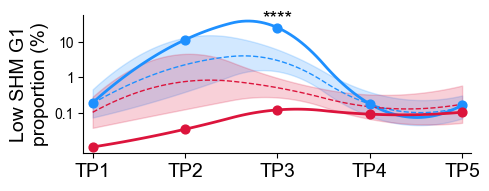

In [6]:
plt.rcParams["figure.figsize"] = (5, 2)
fig,ax = plt.subplots(1,1)
temp = subject_dict[high_ref_subject]
spline_dim = 2
val_index = 0
high_ref_val_list = []
for j in range(5):
    high_ref_val_list.append(np.log10(temp[j][val_index]))
plt.scatter(range(5),high_ref_val_list,color=color_list[0],s=40,zorder=20)

x_new = np.linspace(0,4, 100)
spl1 = make_interp_spline(range(5), [np.median(np.array(x)) for x in high_ref_val_list], k=spline_dim)  # cubic spline
y1_smooth = spl1(x_new)  
plt.plot(x_new,y1_smooth,color=color_list[0],marker='',linewidth=2,zorder=10)

temp = subject_dict[low_ref_subject]
low_ref_val_list = []
for j in range(5):
    low_ref_val_list.append(np.log10(temp[j][val_index]))
plt.scatter(range(5),low_ref_val_list,color=color_list[1],s=40,zorder=20)

x_new = np.linspace(0,4, 100)
spl1 = make_interp_spline(range(5), [np.median(np.array(x)) for x in low_ref_val_list], k=spline_dim)  # cubic spline
y1_smooth = spl1(x_new)  
plt.plot(x_new,y1_smooth,color=color_list[1],marker='',linewidth=2,zorder=10)

high_val_list = []
for j in range(5):
    high_val_list.append([])
for subject in high_subject:
    temp = subject_dict[subject]
    for j in range(5):
        if temp[j][val_index] != 0:
            high_val_list[j].append(np.log10(temp[j][val_index]))
medians = np.array([np.median(np.array(x)) for x in high_val_list])
stds = np.array([np.std(np.array(x)) for x in high_val_list])
highs = medians+stds
lows = medians-stds
x_new = np.linspace(0,4, 100)
spl1 = make_interp_spline(range(5), [np.median(np.array(x)) for x in medians], k=spline_dim)  # cubic spline
y1_smooth = spl1(x_new)  
plt.plot(x_new,y1_smooth,color=color_list[0],marker='',linewidth=1,linestyle = '--',zorder=10)
splhigh = make_interp_spline(range(5), [np.median(np.array(x)) for x in highs], k=spline_dim)  # cubic spline
yhigh_smooth = splhigh(x_new)  
spllow = make_interp_spline(range(5), [np.median(np.array(x)) for x in lows], k=spline_dim)  # cubic spline
ylow_smooth = spllow(x_new) 
plt.fill_between(x_new, yhigh_smooth, ylow_smooth, color=color_list[0], alpha=0.2,zorder=0)

low_val_list = []
for j in range(5):
    low_val_list.append([])
for subject in low_subject:
    temp = subject_dict[subject]
    for j in range(5):
        if temp[j][val_index] != 0:
            low_val_list[j].append(np.log10(temp[j][val_index]))
medians = np.array([np.median(np.array(x)) for x in low_val_list])
stds = np.array([np.std(np.array(x)) for x in low_val_list])
highs = medians+stds
lows = medians-stds
x_new = np.linspace(0,4, 100)
spl1 = make_interp_spline(range(5), [np.median(np.array(x)) for x in medians], k=spline_dim)  # cubic spline
y1_smooth = spl1(x_new)  
plt.plot(x_new,y1_smooth,color=color_list[1],marker='',linewidth=1,linestyle = '--',zorder=10)
splhigh = make_interp_spline(range(5), [np.median(np.array(x)) for x in highs], k=spline_dim)  # cubic spline
yhigh_smooth = splhigh(x_new)  
spllow = make_interp_spline(range(5), [np.median(np.array(x)) for x in lows], k=spline_dim)  # cubic spline
ylow_smooth = spllow(x_new) 
plt.fill_between(x_new, yhigh_smooth, ylow_smooth, color=color_list[1], alpha=0.2,zorder=0)

for j in range(5):
    t,p = mannwhitneyu(low_val_list[j],high_val_list[j])
    print('TP'+str(j+1)+':', p)
    text = ''
    if p <= 0.05:
        text += '*'
    if p <= 0.01:
        text += '*'
    if p <= 0.001:
        text += '*'
    if p <= 0.0001:
        text += '*'
    plt.text(j,max(high_ref_val_list[j],low_ref_val_list[j]),text,color='k',font='arial',fontsize=14,ha='center',va='bottom')
    
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.ylabel('Low SHM G1\nproportion (%)',font='arial',fontsize=14)
plt.xticks(range(5),['TP1','TP2','TP3','TP4','TP5'],font='arial',fontsize=14)
plt.yticks([-1,0,1],['0.1','1','10'],font='arial',fontsize=14)
plt.xlim(-0.1,4.1)
plt.yticks(font='arial',fontsize = 10)
plt.tight_layout()
plt.show()

TP1: 0.04020186917706633
TP2: 0.23943189884437377
TP3: 1.3672575056737853e-07
TP4: 0.42535921025852663
TP5: 0.01856969567593295


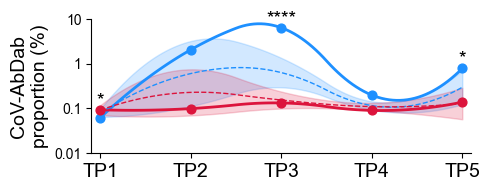

In [7]:
plt.rcParams["figure.figsize"] = (5, 2)
fig,ax = plt.subplots(1,1)
temp = subject_dict[high_ref_subject]
spline_dim = 2
val_index = 2
high_ref_val_list = []
for j in range(5):
    high_ref_val_list.append(np.log10(temp[j][val_index]))
plt.scatter(range(5),high_ref_val_list,color=color_list[0],s=40,zorder=20)

x_new = np.linspace(0,4, 100)
spl1 = make_interp_spline(range(5), [np.median(np.array(x)) for x in high_ref_val_list], k=spline_dim)  # cubic spline
y1_smooth = spl1(x_new)  
plt.plot(x_new,y1_smooth,color=color_list[0],marker='',linewidth=2,zorder=10)

temp = subject_dict[low_ref_subject]
low_ref_val_list = []
for j in range(5):
    low_ref_val_list.append(np.log10(temp[j][val_index]))
plt.scatter(range(5),low_ref_val_list,color=color_list[1],s=40,zorder=20)

x_new = np.linspace(0,4, 100)
spl1 = make_interp_spline(range(5), [np.median(np.array(x)) for x in low_ref_val_list], k=spline_dim)  # cubic spline
y1_smooth = spl1(x_new)  
plt.plot(x_new,y1_smooth,color=color_list[1],marker='',linewidth=2,zorder=10)

high_val_list = []
for j in range(5):
    high_val_list.append([])
for subject in high_subject:
    temp = subject_dict[subject]
    for j in range(5):
        if temp[j][val_index] != 0:
            high_val_list[j].append(np.log10(temp[j][val_index]))
medians = np.array([np.median(np.array(x)) for x in high_val_list])
stds = np.array([np.std(np.array(x)) for x in high_val_list])
highs = medians+stds
lows = medians-stds
x_new = np.linspace(0,4, 100)
spl1 = make_interp_spline(range(5), [np.median(np.array(x)) for x in medians], k=spline_dim)  # cubic spline
y1_smooth = spl1(x_new)  
plt.plot(x_new,y1_smooth,color=color_list[0],marker='',linewidth=1,linestyle = '--',zorder=10)
splhigh = make_interp_spline(range(5), [np.median(np.array(x)) for x in highs], k=spline_dim)  # cubic spline
yhigh_smooth = splhigh(x_new)  
spllow = make_interp_spline(range(5), [np.median(np.array(x)) for x in lows], k=spline_dim)  # cubic spline
ylow_smooth = spllow(x_new) 
plt.fill_between(x_new, yhigh_smooth, ylow_smooth, color=color_list[0], alpha=0.2,zorder=0)

low_val_list = []
for j in range(5):
    low_val_list.append([])
for subject in low_subject:
    temp = subject_dict[subject]
    for j in range(5):
        if temp[j][val_index] != 0:
            low_val_list[j].append(np.log10(temp[j][val_index]))
medians = np.array([np.median(np.array(x)) for x in low_val_list])
stds = np.array([np.std(np.array(x)) for x in low_val_list])
highs = medians+stds
lows = medians-stds
x_new = np.linspace(0,4, 100)
spl1 = make_interp_spline(range(5), [np.median(np.array(x)) for x in medians], k=spline_dim)  # cubic spline
y1_smooth = spl1(x_new)  
plt.plot(x_new,y1_smooth,color=color_list[1],marker='',linewidth=1,linestyle = '--',zorder=10)
splhigh = make_interp_spline(range(5), [np.median(np.array(x)) for x in highs], k=spline_dim)  # cubic spline
yhigh_smooth = splhigh(x_new)  
spllow = make_interp_spline(range(5), [np.median(np.array(x)) for x in lows], k=spline_dim)  # cubic spline
ylow_smooth = spllow(x_new) 
plt.fill_between(x_new, yhigh_smooth, ylow_smooth, color=color_list[1], alpha=0.2,zorder=0)

for j in range(5):
    t,p = mannwhitneyu(low_val_list[j],high_val_list[j])
    print('TP'+str(j+1)+':', p)
    text = ''
    if p <= 0.05:
        text += '*'
    if p <= 0.01:
        text += '*'
    if p <= 0.001:
        text += '*'
    if p <= 0.0001:
        text += '*'
    plt.text(j,max(high_ref_val_list[j],low_ref_val_list[j]),text,color='k',font='arial',fontsize=14,ha='center',va='bottom')
    
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.ylabel('CoV-AbDab\nproportion (%)',font='arial',fontsize=14)
plt.xticks(range(5),['TP1','TP2','TP3','TP4','TP5'],font='arial',fontsize=14)
plt.yticks([-2,-1,0,1],['0.01','0.1','1','10'],font='arial',fontsize=14)
plt.xlim(-0.1,4.1)
plt.yticks(font='arial',fontsize = 10)
plt.tight_layout()
plt.show()

0.18553734869502958
0.12579499481530182
0.0015183925876980772
0.3476306646675037
0.02138538642300657


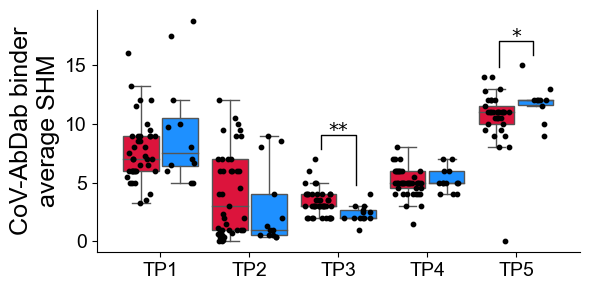

In [8]:
tp_dict = {'pre':0,'1st':1,'2nd':2,'3rd':3,'5th':4}
temp_list = tools.read_csv('BCRmap/all_vaccination_binder_shm_median.csv')
high_box = [[],[],[],[],[]]
for line in temp_list[1:]:
    if line[1].split('-')[0] in tp_dict:
        tp = tp_dict[line[1].split('-')[0]]
        subject = line[1].split('-')[1]
        if subject in high_subject:
            high_box[tp].append(float(line[2]))

low_box = [[],[],[],[],[]]
for line in temp_list[1:]:
    if line[1].split('-')[0] in tp_dict:
        tp = tp_dict[line[1].split('-')[0]]
        subject = line[1].split('-')[1]
        if subject in low_subject:
            low_box[tp].append(float(line[2]))

plt.rcParams["figure.figsize"] = (6, 3)
fig,ax = plt.subplots(1,1)
label_list = ['TP1','TP2','TP3','TP4','TP5']
color_list = ['dodgerblue','crimson']
b = 0.22
width = 0.4
linewidth=1
positions_list = list(b+np.array(range(len(label_list))))
plt.boxplot(high_box, positions=positions_list, widths=[width]*len(label_list), patch_artist=True, showfliers=False,
            boxprops={'facecolor': color_list[0], 'edgecolor': '#555555', 'linewidth': linewidth},
            whiskerprops={'color': '#555555', 'linewidth': linewidth},
            capprops={'color': '#555555', 'linewidth': linewidth},
            medianprops={'color': '#555555', 'linewidth': linewidth})
for v,val_list in enumerate(high_box):
    plt.scatter([v+b+0.8*width*(rd.random()-0.5) for x in val_list],val_list,
               color='k',s=10,zorder=40)

positions_list = list(-b+np.array(range(len(label_list))))
plt.boxplot(low_box, positions=positions_list, widths=[width]*len(label_list), patch_artist=True, showfliers=False,
            boxprops={'facecolor': color_list[1], 'edgecolor': '#555555', 'linewidth': linewidth},
            whiskerprops={'color': '#555555', 'linewidth': linewidth},
            capprops={'color': '#555555', 'linewidth': linewidth},
            medianprops={'color': '#555555', 'linewidth': linewidth})
for v,val_list in enumerate(low_box):
    plt.scatter([v-b+0.8*width*(rd.random()-0.5) for x in val_list],val_list,
               color='k',s=10,zorder=40)

max_val = 41
min_val = min([min(x) for x in low_box])
y_bias = 0.02 * (max_val - min_val)
x_bias = 0.05

for j in range(len(label_list)):
    p = plot_significance(high_box[j], low_box[j], j-b+0.025, j+b-0.025,
                          max(low_box[j])+y_bias,max(high_box[j])+y_bias, 1.5*y_bias, 14, 1)

                    
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.ylabel('CoV-AbDab binder\naverage SHM',font='arial',fontsize=18)
plt.xticks(range(len(label_list)),label_list,font='arial',fontsize = 14)
plt.yticks(font='arial',fontsize = 14)
plt.tight_layout()
plt.show()